In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [369]:
# Reading Datasets in
industrial_df = pd.read_csv('SP500_Industrials_Index_Returns.csv', index_col = [0], parse_dates = True)
Eurostoxx_RE_df = pd.read_csv('Eurostoxx_RealEstate_Sector_Prices.csv',index_col = [0], parse_dates = True)
Eurostoxx_FinS_df = pd.read_csv('Eurostoxx_Financial_Sector_Prices.csv', index_col=[0], parse_dates=True)
NASDAQ_df = pd.read_csv('NASDAQ Index Returns.csv', parse_dates = True, index_col = [0])

### Old Functions

## PCA Functions

In [259]:
def PCA_with_Omitted_Stock2(df, omitted_ticker, PCA_components=2):
    """
    Perform PCA on the stock data after omitting a specific stock ticker.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing stock data with tickers as columns.
    omitted_ticker (str): The ticker to omit from the PCA analysis.
    PCA_components (int): Number of PCA components to retain.
    
    Returns:
    pd.DataFrame: DataFrame containing the PCA results.
    """
    if omitted_ticker == False:
        # If no ticker is omitted, perform PCA on the entire DataFrame
        df_omitted = df.copy()
    else:
        # Omit the specified ticker
        df_omitted = df.drop(columns=[omitted_ticker])
    
   
    # Standardize the data
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_omitted), columns=df_omitted.columns)
    
    # Perform PCA
    pca = PCA(n_components=PCA_components)
    pca_result = pca.fit_transform(df_scaled)

    pca_df = pd.DataFrame({'PCA Explained Variance' : pca.explained_variance_, 
    'PCA Explained Variance Ratio' : pca.explained_variance_ratio_}, index=[f'PC{i+1}' for i in range(PCA_components)])
    
    pca_df['Cumulative Explained Variance Ratio'] = pca_df['PCA Explained Variance Ratio'].cumsum() * 100
    pca_df['Cumulative Explained Variance'] = pca_df['PCA Explained Variance'].cumsum()
    
    # Return PCA Object if omitted ticker is False. Otherwise only return the cumulative variances and ratios
    if omitted_ticker == False:
        return pca_df
    else:
        return pca_df.iloc[- 1, 2], pca_df.iloc[-1, 3]

def PCA_Omitted_Loop2(df, PCA_components):
    """
    Loop through all tickers in the DataFrame and perform PCA after omitting each ticker.
    
    Parameters:
    PCA_components (int): Number of PCA components to retain.
    
    Returns:
    pd.DataFrame: DataFrame containing PCA results for each omitted ticker.
    """
    
    variance_ratios = {}
    variances = {}
    
    # Perform PCA with one ticker omitted at a time
    for ticker in df.columns:
        ratio, variance = PCA_with_Omitted_Stock2(df=df, omitted_ticker=ticker, PCA_components=PCA_components)
        variance_ratios[ticker] = ratio
        variances[ticker] = variance

    # Perform PCA without omitting any tickers to compare 
    PCA_Statistics_ = PCA_with_Omitted_Stock2(df, omitted_ticker=False, PCA_components=PCA_components)
    
    # Putting into one big dataframe to see results
    results = pd.DataFrame({'Explained Variance Ratios' : variance_ratios.values(),
                        'Explained Variances' : variances.values()},
                        index=[i for i in variance_ratios.keys()])

    results['Marginal Variance Ratio'] =  PCA_Statistics_.loc[f'PC{PCA_components}', 'Cumulative Explained Variance Ratio'] - results['Explained Variance Ratios']
    results['Marginal Variance'] =  PCA_Statistics_.loc[f'PC{PCA_components}', 'Cumulative Explained Variance'] -  results['Explained Variances'] 

    return results.sort_values(by='Marginal Variance Ratio', ascending=False)

In [ ]:
def plot_PCA_Results(df):
    """
    Plot the PCA results from the DataFrame.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing PCA results.
    """
    df.index = df.index.get_level_values(level = 0).str[0:5]
    plt.figure(figsize=(12, 6))
    sns.barplot(x=df.index, y='Marginal Variance', data=df)
    plt.xticks(rotation=50)
    plt.title('Variance Contribution by Ticker')
    plt.xlabel('Ticker')
    plt.ylabel('Marginal Variance (Standardized)')
    plt.tight_layout()
    plt.show()

### PCA on S&P Industrial Returns

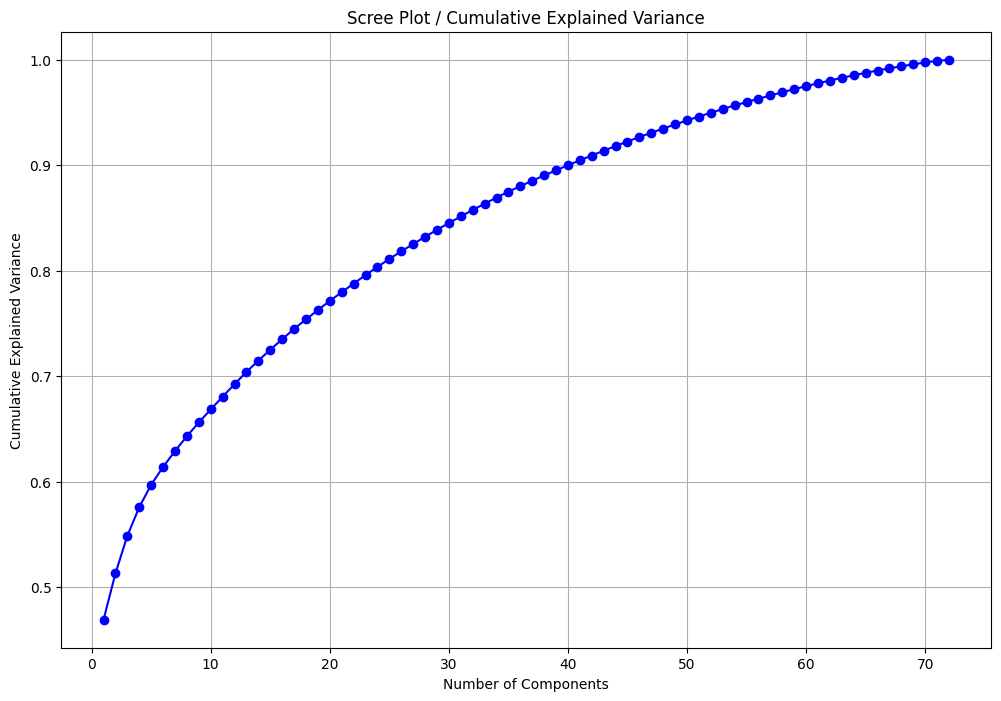

In [237]:
n_components = industrial_df.shape[1]
scaler = StandardScaler()

#Read in data and scale it
X_scaled = scaler.fit_transform(industrial_df)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [238]:
PCA_Statistics = pd.DataFrame({'Explained Variance' : PCA_.explained_variance_, 'Explained Variance Ratio (%)' : PCA_.explained_variance_ratio_}, 
                            index=X_PCA.columns)
PCA_Statistics['Cumulative Explained Variance Ratio'] = PCA_Statistics['Explained Variance Ratio (%)'].cumsum() * 100
PCA_Statistics['Cumulative Explained Variance'] = PCA_Statistics['Explained Variance'].cumsum()

# Find the number of components that explain up to 80% of the variance
PCA_Statistics.loc[PCA_Statistics[PCA_Statistics['Cumulative Explained Variance Ratio'] > 80].index].head(10)

,Explained Variance,Explained Variance Ratio (%),Cumulative Explained Variance Ratio,Cumulative Explained Variance
PC24,0.557383,0.007737,80.363932,57.897356
PC25,0.539087,0.007483,81.112207,58.436443
PC26,0.524449,0.007280,81.840164,58.960892
PC27,0.499678,0.006936,82.533739,59.460571
PC28,0.489236,0.006791,83.212819,59.949807
PC29,0.484272,0.006722,83.885009,60.434079
PC30,0.456045,0.006330,84.518018,60.890124
PC31,0.451421,0.006266,85.144609,61.341544
PC32,0.441537,0.006129,85.757481,61.783082
PC33,0.428051,0.005942,86.351634,62.211133


We need 42 principal components to explain 80% of the variance within the S&P industrials index. We can now use the PCA-based subsetting methodology to identify a small number of stocks that can best replicate this. Below shows the 5 stocks once omitted from a PCA on the S&P industrials index members with the largest increase in variances (thus the 5 stocks with the most explanatory power). A plot is also shown of each index member's contribution to the total variance of the index via the omitted variable analysis

In [261]:
industrial_PCA_results = PCA_Omitted_Loop2(industrial_df, PCA_components=24)
industrial_PCA_results_sorted = industrial_PCA_results.sort_values(by='Marginal Variance', ascending=False).copy()
Industrial_Top_5_Stocks = industrial_PCA_results_sorted.head(5).index
print('Stocks chosen : ', Industrial_Top_5_Stocks)
industrial_PCA_results_sorted.head(5)


Stocks chosen :  Index(['DAL', 'PH', 'UAL', 'RSG', 'ETN'], dtype='object')


,Explained Variance Ratios,Explained Variances,Marginal Variance Ratio,Marginal Variance
DAL,80.302837,57.049822,0.061095,0.847534
PH,80.319674,57.061784,0.044258,0.835572
UAL,80.325326,57.065799,0.038606,0.831557
RSG,80.332626,57.070985,0.031307,0.826371
ETN,80.351716,57.084547,0.012216,0.812809


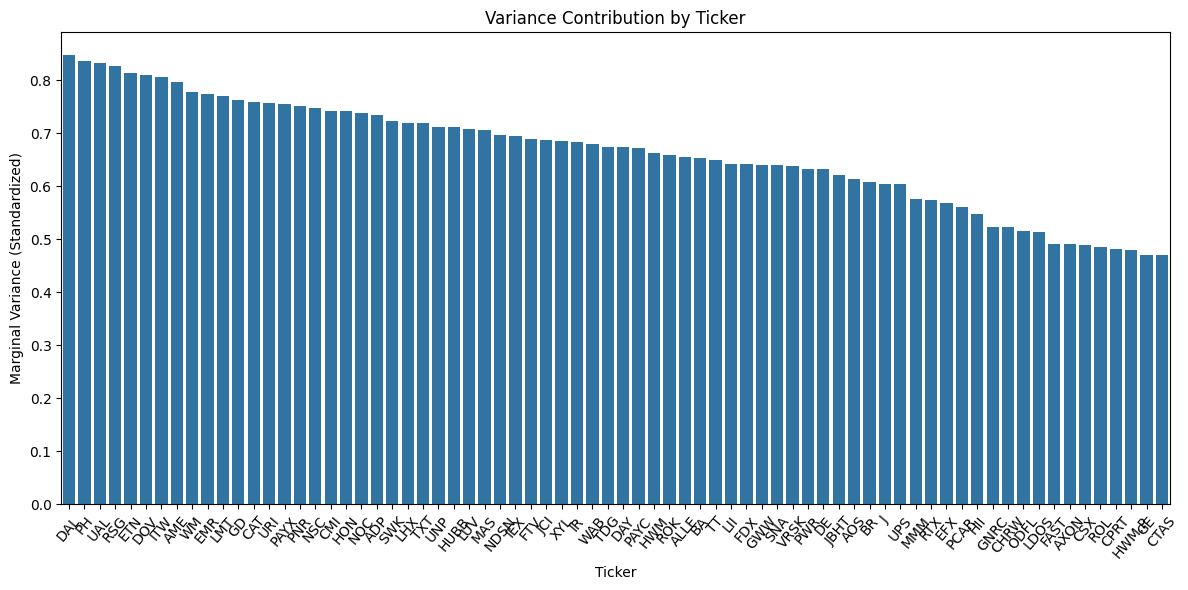

In [240]:
plot_PCA_Results(industrial_PCA_results)

### Eurostoxx Financial Sector Index PCA

More idiosyncratic -> contribution of each stock via PC components is small

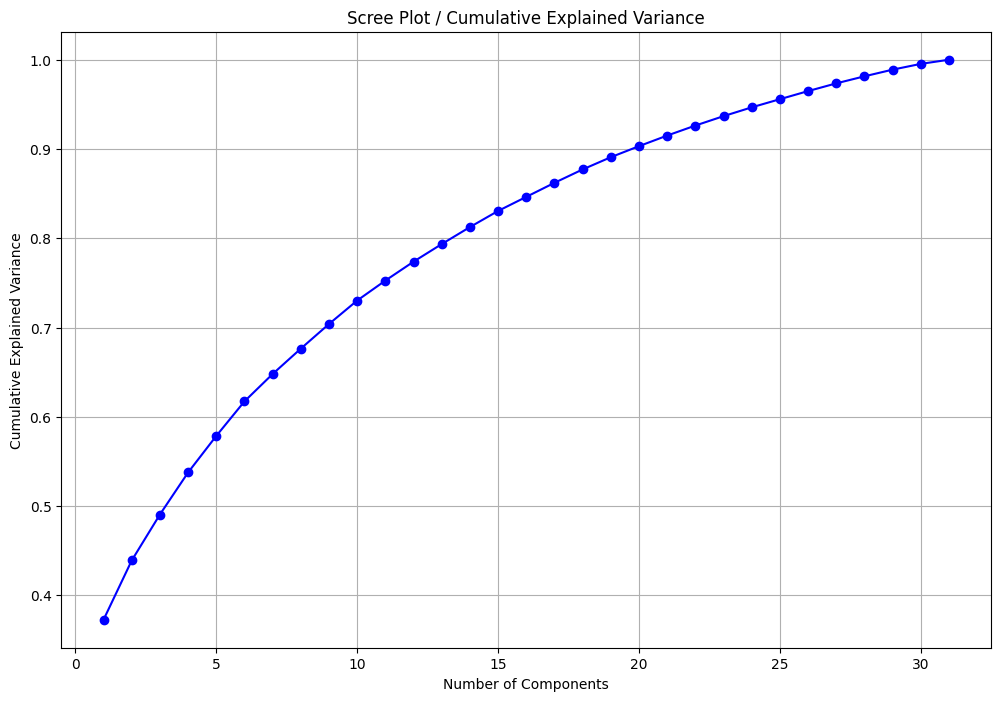

In [303]:
df = Eurostoxx_FinS_df.copy().loc['2024-05-01':'2025-02-01']
n_components = df.shape[1]
    
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Run PCA
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(df_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [304]:
PCA_Statistics = pd.DataFrame({'Explained Variance' : PCA_.explained_variance_, 'Explained Variance Ratio (%)' : PCA_.explained_variance_ratio_}, 
                            index=X_PCA.columns)
PCA_Statistics['Cumulative Explained Variance Ratio'] = PCA_Statistics['Explained Variance Ratio (%)'].cumsum() * 100
PCA_Statistics['Cumulative Explained Variance'] = PCA_Statistics['Explained Variance'].cumsum()

# Find the number of components that explain up to 90% of the variance
PCA_Statistics.loc[PCA_Statistics[PCA_Statistics['Cumulative Explained Variance Ratio'] > 80].index]

,Explained Variance,Explained Variance Ratio (%),Cumulative Explained Variance Ratio,Cumulative Explained Variance
PC14,0.593193,0.019039,81.251093,25.315696
PC15,0.563248,0.018078,83.058846,25.878944
PC16,0.491412,0.015772,84.636039,26.370356
PC17,0.490150,0.015731,86.209182,26.860506
PC18,0.467107,0.014992,87.708369,27.327613
PC19,0.427440,0.013719,89.080243,27.755052
PC20,0.385298,0.012366,90.316861,28.140350
PC21,0.369886,0.011872,91.504015,28.510236
PC22,0.349346,0.011212,92.625248,28.859582
PC23,0.328570,0.010545,93.679797,29.188152


In [305]:
Eurostoxx_FinS_Results = PCA_Omitted_Loop2(Eurostoxx_FinS_df, PCA_components=14)
Eurostoxx_FinS_Results = Eurostoxx_FinS_Results.sort_values(by='Marginal Variance', ascending=False).copy()
Eurostoxx_FinS_Top_5 = Eurostoxx_FinS_Results.head(5).index
print('Stocks chosen : ', Eurostoxx_FinS_Top_5)

Eurostoxx_FinS_Results.head(5)

Stocks chosen :  Index(['GROUPE BRUXELLES LAMBERT', 'INDUSTRIVARDEN AB', 'AZIMUT HOLDING SPA',
       'BANCA MEDIOLANUM', 'WENDEL'],
      dtype='object')


,Explained Variance Ratios,Explained Variances,Marginal Variance Ratio,Marginal Variance
GROUPE BRUXELLES LAMBERT,80.954487,24.300906,-0.227465,0.739474
INDUSTRIVARDEN AB,81.009911,24.317544,-0.282889,0.722837
AZIMUT HOLDING SPA,81.077404,24.337803,-0.350382,0.702577
BANCA MEDIOLANUM,81.080611,24.338766,-0.353589,0.701614
WENDEL,81.097747,24.343910,-0.370725,0.696470


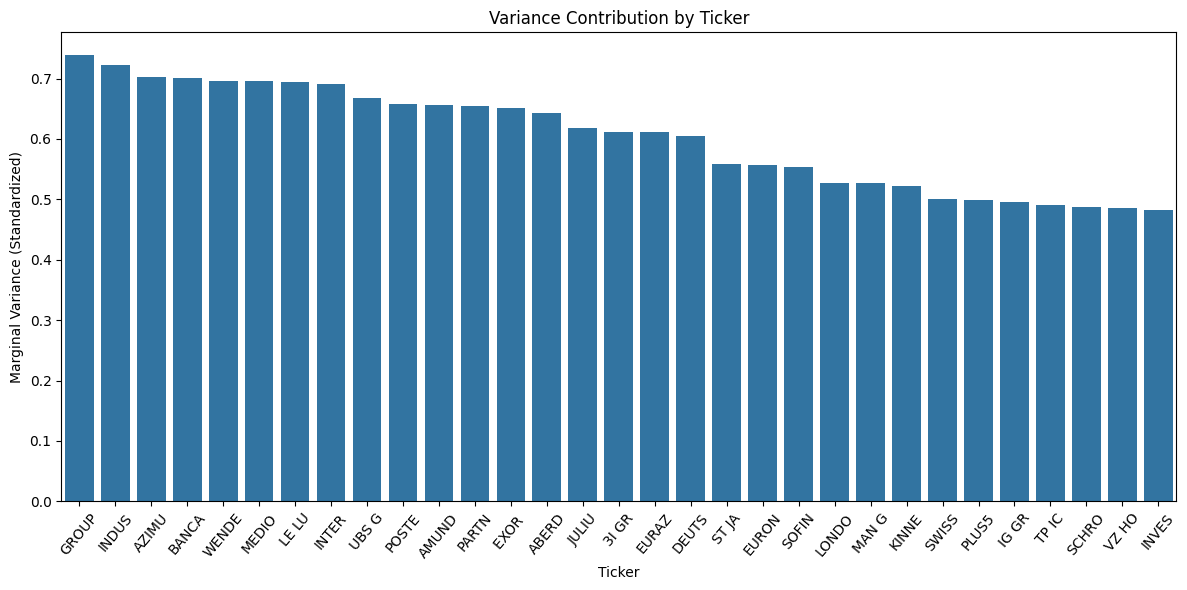

In [306]:
plot_PCA_Results(Eurostoxx_FinS_Results)

### Eurostoxx Real Estate PCA Analysis

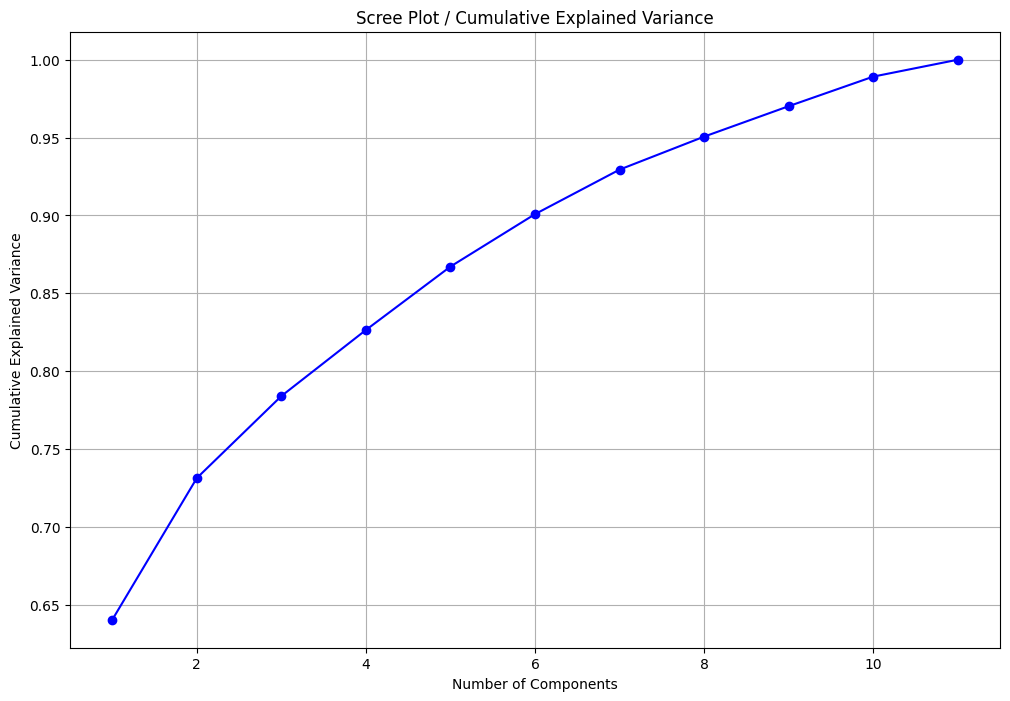

In [307]:
df = Eurostoxx_RE_df.copy().loc['2024-05-01':'2025-02-01']
n_components = df.shape[1]
    
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Run PCA
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(df_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [308]:
PCA_Statistics = pd.DataFrame({'Explained Variance' : PCA_.explained_variance_, 'Explained Variance Ratio (%)' : PCA_.explained_variance_ratio_}, 
                            index=X_PCA.columns)
PCA_Statistics['Cumulative Explained Variance Ratio'] = PCA_Statistics['Explained Variance Ratio (%)'].cumsum() * 100
PCA_Statistics['Cumulative Explained Variance'] = PCA_Statistics['Explained Variance'].cumsum()

# Find the number of components that explain up to 90% of the variance
PCA_Statistics.loc[PCA_Statistics[PCA_Statistics['Cumulative Explained Variance Ratio'] > 80].index]

,Explained Variance,Explained Variance Ratio (%),Cumulative Explained Variance Ratio,Cumulative Explained Variance
PC4,0.468968,0.042418,82.647208,9.137341
PC5,0.450253,0.040725,86.719742,9.587594
PC6,0.372041,0.033651,90.084855,9.959635
PC7,0.316087,0.028590,92.943862,10.275722
PC8,0.234179,0.021182,95.062014,10.509902
PC9,0.216015,0.019539,97.015872,10.725917
PC10,0.209938,0.018989,98.914764,10.935856
PC11,0.119982,0.010852,100.000000,11.055838


In [309]:
Eurostoxx_RE_df_results = PCA_Omitted_Loop2(Eurostoxx_RE_df, PCA_components=4)
Eurostoxx_RE_PCA_results_sorted = Eurostoxx_RE_df_results.sort_values(by='Marginal Variance', ascending=False).copy()
Eurostoxx_RE_Top_5_Stocks = Eurostoxx_RE_PCA_results_sorted.head(5).index
print('Stocks chosen : ', Eurostoxx_RE_Top_5_Stocks)
Eurostoxx_RE_PCA_results_sorted.head(5)


Stocks chosen :  Index(['LEG IMMOBILIEN SE', 'VONOVIA SE', 'TAG IMMOBILIEN AG', 'KLEPIERRE SA',
       'UNIBAIL RODAMCO WESTFIELD SE'],
      dtype='object')


,Explained Variance Ratios,Explained Variances,Marginal Variance Ratio,Marginal Variance
LEG IMMOBILIEN SE,82.060758,8.210995,-0.036399,0.817093
VONOVIA SE,82.345489,8.239486,-0.321131,0.788603
TAG IMMOBILIEN AG,82.744011,8.279362,-0.719652,0.748727
KLEPIERRE SA,82.755385,8.280500,-0.731026,0.747589
UNIBAIL RODAMCO WESTFIELD SE,82.851467,8.290114,-0.827108,0.737975


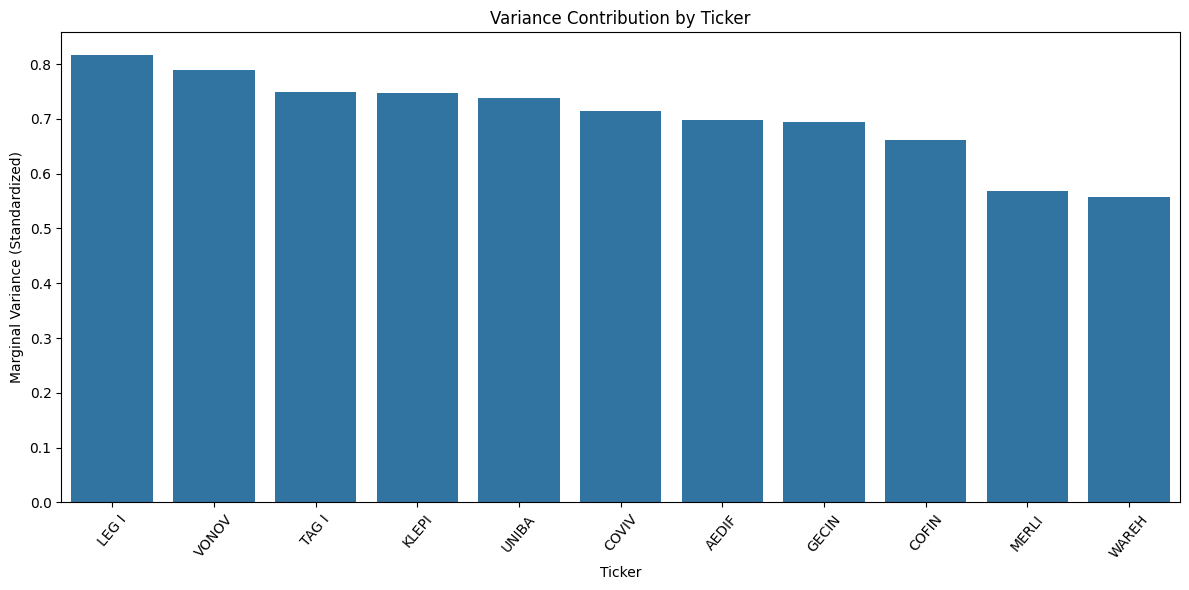

In [310]:
plot_PCA_Results(Eurostoxx_RE_df_results)

### NASDAQ 100 PCA Analysis

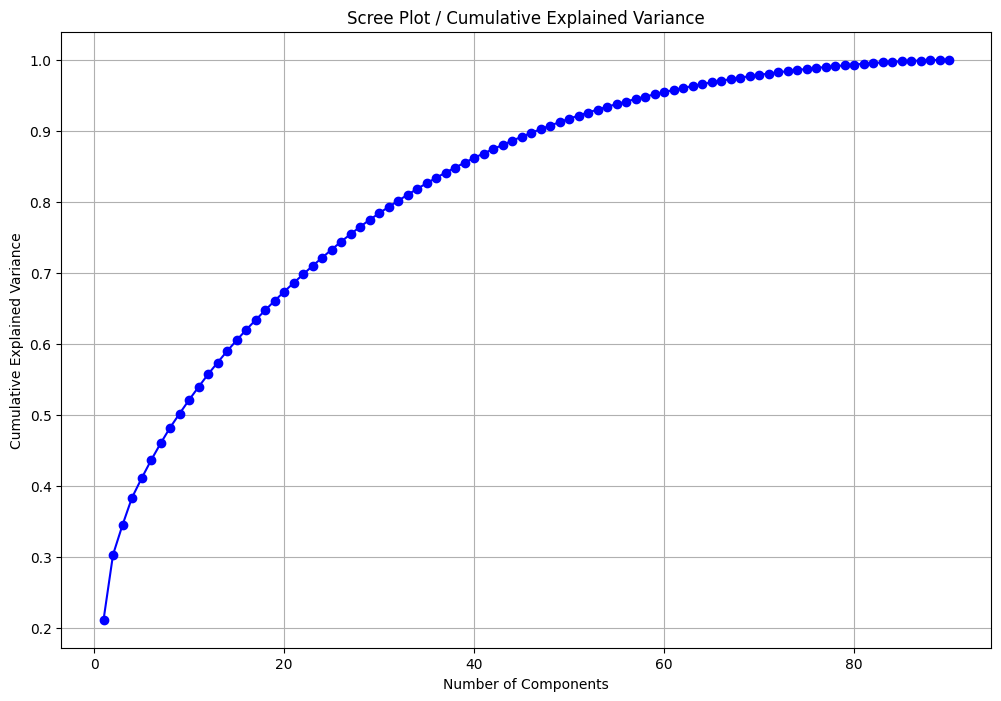

In [370]:
df = NASDAQ_df.copy().loc['2024-05-01':'2025-02-01']
n_components = df.shape[1]
    
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Run PCA
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(df_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])

plt.figure(figsize = (12, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [371]:
PCA_Statistics = pd.DataFrame({'Explained Variance' : PCA_.explained_variance_, 'Explained Variance Ratio (%)' : PCA_.explained_variance_ratio_}, 
                            index=X_PCA.columns)
PCA_Statistics['Cumulative Explained Variance Ratio'] = PCA_Statistics['Explained Variance Ratio (%)'].cumsum() * 100
PCA_Statistics['Cumulative Explained Variance'] = PCA_Statistics['Explained Variance'].cumsum()

# Find the number of components that explain up to 90% of the variance
PCA_Statistics.loc[PCA_Statistics[PCA_Statistics['Cumulative Explained Variance Ratio'] > 80].index]

,Explained Variance,Explained Variance Ratio (%),Cumulative Explained Variance Ratio,Cumulative Explained Variance
PC32,0.787426,0.008704,80.144854,72.502174
PC33,0.766649,0.008475,80.992317,73.268823
PC34,0.747802,0.008266,81.818948,74.016625
PC35,0.716188,0.007917,82.610632,74.732814
PC36,0.689801,0.007625,83.373147,75.422615
PC37,0.672186,0.007430,84.116190,76.094801
PC38,0.630537,0.006970,84.813195,76.725338
PC39,0.624504,0.006903,85.503529,77.349842
PC40,0.611361,0.006758,86.179336,77.961203
PC41,0.564144,0.006236,86.802949,78.525348


In [372]:
NASDAQ_results = PCA_Omitted_Loop2(NASDAQ_df, PCA_components=32)
NASDAQ_PCA_results_sorted = NASDAQ_results.sort_values(by='Marginal Variance', ascending=False).copy()
NASDAQ_Top_5_Stocks = NASDAQ_PCA_results_sorted.head(5).index
print('Stocks chosen : ', NASDAQ_Top_5_Stocks)
NASDAQ_PCA_results_sorted.head(5)

Stocks chosen :  Index(['ADI', 'AMAT', 'NXPI', 'KLAC', 'TXN'], dtype='object')


,Explained Variance Ratios,Explained Variances,Marginal Variance Ratio,Marginal Variance
ADI,75.155786,66.929510,0.083100,0.826853
AMAT,75.159520,66.932836,0.079366,0.823527
NXPI,75.169826,66.942013,0.069060,0.814349
KLAC,75.170022,66.942187,0.068864,0.814175
TXN,75.177856,66.949164,0.061030,0.807198


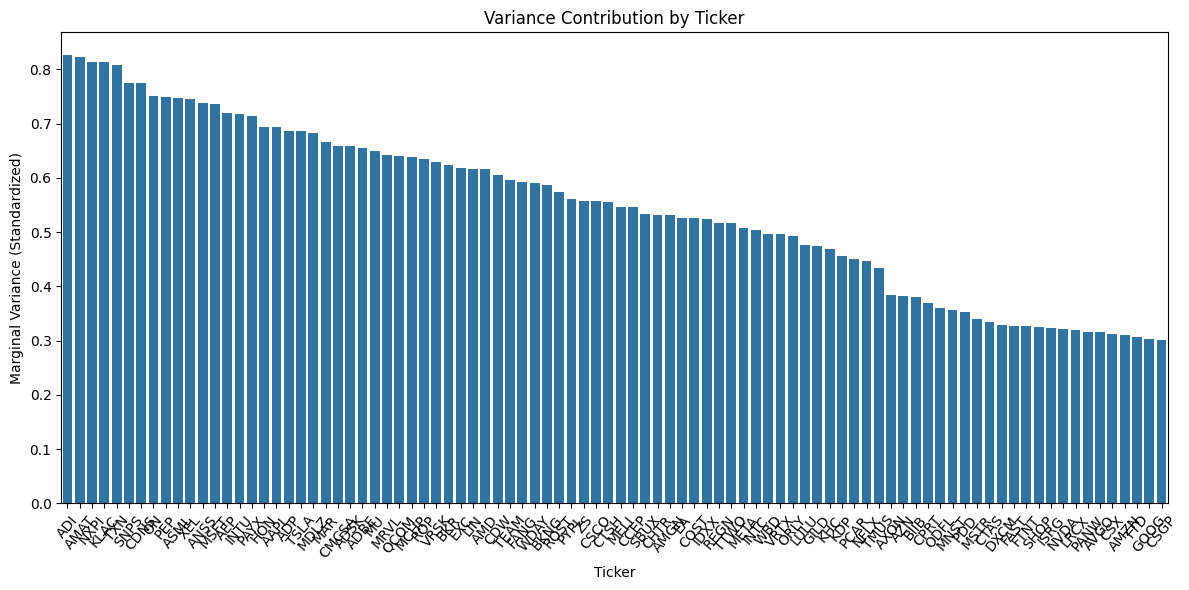

In [373]:
plot_PCA_Results(NASDAQ_results)

### Correlation Realized (Monthly)

In [397]:
# Returns of Chosen Stocks

def realized_corr_monthly(returns_df):
    """
    
    Returns a multiple indexed tensor-like DataFrame with index (date, stock_i, stock_j etc) showing
    realized monthly correlation matrices
    """
    df = returns_df.copy()
    df.index = pd.to_datetime(df.index)

    corr_dict = {
        period_end: group.corr()
        for period_end, group in df.resample('ME')
    }
    result = pd.concat(corr_dict)

    result.index.name = ('Date', 'Stock 1')
    result.columns.name = 'Stock'
    return result

In [398]:
NASDAQ_Top_5_Stocks_df = NASDAQ_df[NASDAQ_Top_5_Stocks].copy()
Eurostoxx_FS_Top_5_Stocks_df = Eurostoxx_FinS_df[Eurostoxx_FinS_Top_5].copy()
Eurostoxx_RE_Top_5_Stocks_df = Eurostoxx_RE_df[Eurostoxx_RE_Top_5_Stocks].copy()
Industrial_Top_5_Stocks_df = industrial_df[Industrial_Top_5_Stocks].copy()

In [399]:
NASDAQ_Stock_RealizedCorr = realized_corr_monthly(NASDAQ_Top_5_Stocks_df)
Eurostoxx_FS_Stock_RealizedCorr = realized_corr_monthly(Eurostoxx_FS_Top_5_Stocks_df)
Eurostoxx_RE_Stock_RealizedCorr = realized_corr_monthly(Eurostoxx_RE_Top_5_Stocks_df)
Industrial_Stock_RealizedCorr = realized_corr_monthly(Industrial_Top_5_Stocks_df)